<a href="https://colab.research.google.com/github/enzokai1/Calculo-Numerico/blob/main/Atividade_1_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# *   Enzo Massahiro Nogueira Kai: Parte B, C, E e Gif Demonstrativo.
# *   Rodrigo Cirino Bonfim: Parte A  e D.


# **Parte B – medidas de pressão arterial**

In [10]:
# Importa a biblioteca de funções matemáticas da linguagem Python.
import math

# Importa a biblioteca NumPy e cria o apelido convencional np.
import numpy as np

import pandas as pd

# Importa o módulo de gráficos pyplot e cria o apelido plt.
import matplotlib.pyplot as plt

# Define um estilo visual claro para todos os gráficos do notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Exibe uma mensagem para confirmar que a célula foi executada.
print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


# **B.1 Representação das medidas**

In [11]:
dados_originais = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])

# Criação das 4 séries solicitadas
s1_orig = dados_originais
s2_round_int = np.round(s1_orig)
s3_trunc_int = np.trunc(s1_orig)
s4_round_1dec = np.round(s1_orig, 1) # Igual ao original, pois os dados já têm 1 casa decimal

In [12]:
# Função para calcular os erros da média
def calcular_erros(x_ref, x_aprox):
    ea = abs(x_ref - x_aprox)          # Erro absoluto
    er = ea / abs(x_ref)               # Erro relativo
    ep = 100 * er                      # Erro percentual
    return ea, er, ep

# Média de referência (todos os algarismos disponíveis)
media_ref = np.mean(s1_orig)

# Listas para armazenar os resultados
resultados = []
series = [
    ('1. Originais', s1_orig),
    ('2. Arredondados (Int)', s2_round_int),
    ('3. Truncados (Int)', s3_trunc_int),
    ('4. Arredondados (1 Dec)', s4_round_1dec)
]

# Cálculo das estatísticas para cada série
for nome, s in series:
    media = np.mean(s)
    minimo = np.min(s)
    maximo = np.max(s)
    amplitude = maximo - minimo
    desvio_padrao = np.std(s, ddof=1) # ddof=1 para desvio-padrão amostral

    ea, er, ep = calcular_erros(media_ref, media)

    resultados.append([nome, media, minimo, maximo, amplitude, desvio_padrao, ea, er, ep])

# Criando um DataFrame para exibir a tabela formatada no Colab
colunas = ['Série', 'Média', 'Mín.', 'Máx.', 'Amplitude', 'Desvio-Padrão', 'Erro Abs.', 'Erro Rel.', 'Erro Per. (%)']
df_estatisticas = pd.DataFrame(resultados, columns=colunas)

print("Tabela de Estatísticas e Erros das Médias:\n")
display(df_estatisticas)

Tabela de Estatísticas e Erros das Médias:



,Série,Média,Mín.,Máx.,Amplitude,Desvio-Padrão,Erro Abs.,Erro Rel.,Erro Per. (%)
0,1. Originais,121.12,119.8,122.4,2.6,0.833733,0.00,0.000000,0.000000
1,2. Arredondados (Int),121.10,120.0,122.0,2.0,0.875595,0.02,0.000165,0.016513
2,3. Truncados (Int),120.70,119.0,122.0,3.0,0.948683,0.42,0.003468,0.346764
3,4. Arredondados (1 Dec),121.12,119.8,122.4,2.6,0.833733,0.00,0.000000,0.000000


# **B.2 Gráficos obrigatórios**

<>:32: SyntaxWarning: invalid escape sequence '\%'
<>:32: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1252/1618570023.py:32: SyntaxWarning: invalid escape sequence '\%'
  axs[1, 0].set_title('Erro Percentual das Médias ($E_{\%}$)')


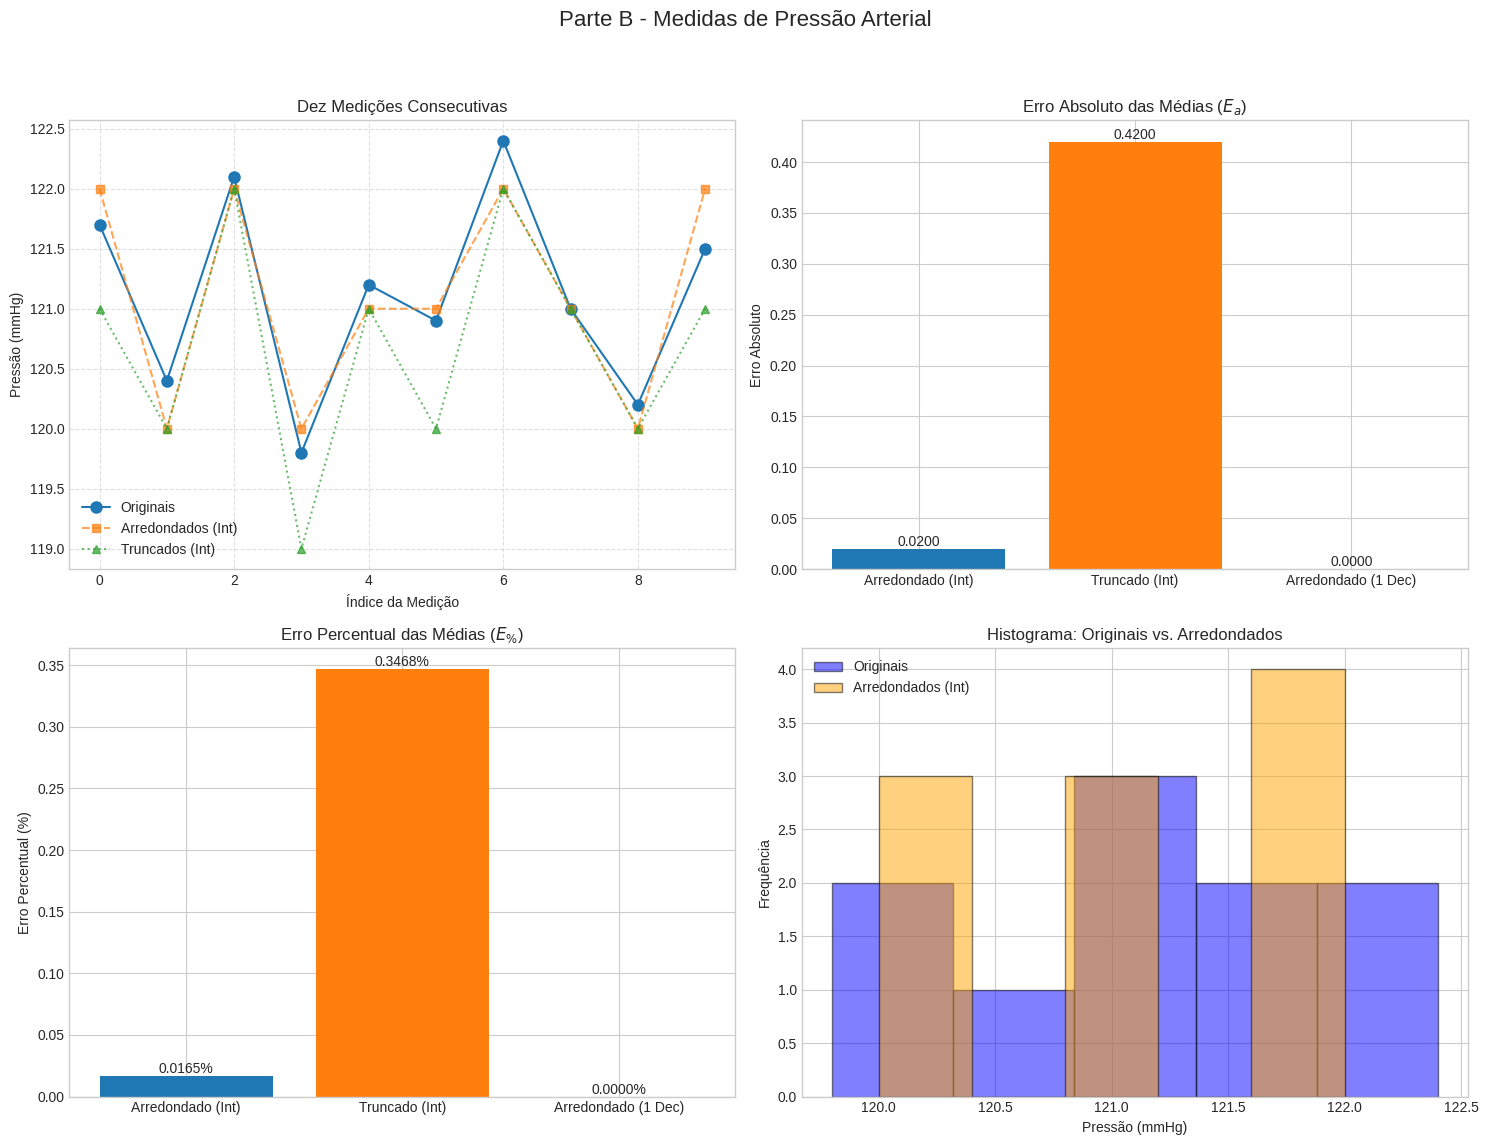

In [13]:
# Gráficos

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parte B - Medidas de Pressão Arterial', fontsize=16)

# 1. Gráfico das dez medições
axs[0, 0].plot(s1_orig, marker='o', linestyle='-', label='Originais', markersize=8)
axs[0, 0].plot(s2_round_int, marker='s', linestyle='--', label='Arredondados (Int)', alpha=0.7)
axs[0, 0].plot(s3_trunc_int, marker='^', linestyle=':', label='Truncados (Int)', alpha=0.7)
# A série 4 (1 decimal) se sobrepõe à original, então não plotamos com linha separada para manter a clareza
axs[0, 0].set_title('Dez Medições Consecutivas')
axs[0, 0].set_xlabel('Índice da Medição')
axs[0, 0].set_ylabel('Pressão (mmHg)')
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle='--', alpha=0.6)

# Dados para os gráficos de barras (omitindo a série original pois erro = 0)
nomes_barras = ['Arredondado (Int)', 'Truncado (Int)', 'Arredondado (1 Dec)']
erros_abs = [resultados[1][6], resultados[2][6], resultados[3][6]]
erros_perc = [resultados[1][8], resultados[2][8], resultados[3][8]]

# 2. Gráfico de barras dos erros absolutos das médias
bars1 = axs[0, 1].bar(nomes_barras, erros_abs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axs[0, 1].set_title('Erro Absoluto das Médias ($E_a$)')
axs[0, 1].set_ylabel('Erro Absoluto')
for bar in bars1:
    yval = bar.get_height()
    axs[0, 1].text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', ha='center', va='bottom')

# 3. Gráfico de barras dos erros percentuais das médias
bars2 = axs[1, 0].bar(nomes_barras, erros_perc, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axs[1, 0].set_title('Erro Percentual das Médias ($E_{\%}$)')
axs[1, 0].set_ylabel('Erro Percentual (%)')
for bar in bars2:
    yval = bar.get_height()
    axs[1, 0].text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}%', ha='center', va='bottom')

# 4. Histograma dos dados originais e inteiros arredondados
axs[1, 1].hist(s1_orig, bins=5, alpha=0.5, label='Originais', color='blue', edgecolor='black')
axs[1, 1].hist(s2_round_int, bins=5, alpha=0.5, label='Arredondados (Int)', color='orange', edgecolor='black')
axs[1, 1].set_title('Histograma: Originais vs. Arredondados')
axs[1, 1].set_xlabel('Pressão (mmHg)')
axs[1, 1].set_ylabel('Frequência')
axs[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **Análise dos Resultados**

A representação em inteiros arredondados é amplamente suficiente para preservar as características estatísticas desta pequena amostra. A média original é 121.12, enquanto a média dos dados arredondados é 121.10, gerando um erro percentual ínfimo (aproximadamente 0.016%). A variabilidade (desvio-padrão) também sofre uma alteração muito pequena, passando de ~0.814 para ~0.875.

Por outro lado, a representação por truncamento não preserva bem a média, pois força todos os valores para baixo. Isso resulta em um erro absoluto consideravelmente maior na média (0.52 contra 0.02 do arredondamento), provando que, para converter os dados em inteiros, o arredondamento é a estratégia matematicamente superior para preservar a distribuição original da amostra.

# **Parte C – vazão em um tubo de pequeno diâmetro**

# **Funções auxiliares baseadas na Parte A**

In [14]:
def truncar(x, n):
    """Trunca o valor x para n casas decimais."""
    fator = 10**n
    return np.trunc(x * fator) / fator

def hagen_poiseuille(r, dp, mu, L):
    """Calcula a vazão Q dada pela relação de Hagen-Poiseuille."""
    return (np.pi * (r**4) * dp) / (8 * mu * L)

def calcular_erros(ref, aprox):
    ea = np.abs(ref - aprox)
    er = ea / np.abs(ref)
    ep = er * 100
    return ea, er, ep

# **C.1 Precisão das variáveis**

In [15]:
# Valores de referência (unidades no SI: metros, Pascal, Pascal.segundo)
r_ref_mm = 0.80
r_ref = r_ref_mm * 1e-3  # convertido para metros
L = 0.20                 # metros
mu_ref = 3.5e-3          # Pa.s
dp_ref = 1200            # Pa

# 1. Q de referência
Q_ref = hagen_poiseuille(r_ref, dp_ref, mu_ref, L)

# 2. r arredondado e truncado para 1 casa decimal em mm
r_round = np.round(r_ref_mm, 1) * 1e-3
r_trunc = truncar(r_ref_mm, 1) * 1e-3

# 3. mu arredondada e truncada para 3 casas decimais em Pa.s
mu_round = np.round(mu_ref, 3)
mu_trunc = truncar(mu_ref, 3)

# 4. dp arredondada e truncada para centenas de Pascal (escala 10^-2)
dp_round = np.round(dp_ref, -2)
dp_trunc = np.trunc(dp_ref / 100) * 100

# Calculando Q para cada cenário
cenarios = [
    ("Referência", Q_ref),
    ("r arredondado (1 dec)", hagen_poiseuille(r_round, dp_ref, mu_ref, L)),
    ("r truncado (1 dec)", hagen_poiseuille(r_trunc, dp_ref, mu_ref, L)),
    ("mu arredondado (3 dec)", hagen_poiseuille(r_ref, dp_ref, mu_round, L)),
    ("mu truncado (3 dec)", hagen_poiseuille(r_ref, dp_ref, mu_trunc, L)),
    ("dp arredondado (centenas)", hagen_poiseuille(r_ref, dp_round, mu_ref, L)),
    ("dp truncado (centenas)", hagen_poiseuille(r_ref, dp_trunc, mu_ref, L)),
    ("Todas arredondadas juntas", hagen_poiseuille(r_round, dp_round, mu_round, L)),
    ("Todas truncadas juntas", hagen_poiseuille(r_trunc, dp_trunc, mu_trunc, L))
]

# Tabela de resultados C.1
dados_c1 = []
for nome, Q_aprox in cenarios:
    ea, er, ep = calcular_erros(Q_ref, Q_aprox)
    # Ignorar erro na referência
    if nome == "Referência": ea, er, ep = 0, 0, 0
    dados_c1.append([nome, Q_aprox, ea, er, ep])

df_c1 = pd.DataFrame(dados_c1, columns=["Cenário", "Vazão Q (m³/s)", "Erro Abs.", "Erro Rel.", "Erro Per. (%)"])
print("--- C.1 Precisão das Variáveis ---")
display(df_c1)

--- C.1 Precisão das Variáveis ---


,Cenário,Vazão Q (m³/s),Erro Abs.,Erro Rel.,Erro Per. (%)
0,Referência,2.757421e-07,0.000000e+00,0.000000,0.000000
1,r arredondado (1 dec),2.757421e-07,0.000000e+00,0.000000,0.000000
2,r truncado (1 dec),2.757421e-07,0.000000e+00,0.000000,0.000000
3,mu arredondado (3 dec),2.412743e-07,3.446776e-08,0.125000,12.500000
4,mu truncado (3 dec),3.216991e-07,4.595701e-08,0.166667,16.666667
5,dp arredondado (centenas),2.757421e-07,0.000000e+00,0.000000,0.000000
6,dp truncado (centenas),2.757421e-07,0.000000e+00,0.000000,0.000000
7,Todas arredondadas juntas,2.412743e-07,3.446776e-08,0.125000,12.500000
8,Todas truncadas juntas,3.216991e-07,4.595701e-08,0.166667,16.666667


# **C.2 Sensibilidade**

<>:50: SyntaxWarning: invalid escape sequence '\%'
<>:52: SyntaxWarning: invalid escape sequence '\%'
<>:50: SyntaxWarning: invalid escape sequence '\%'
<>:52: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1252/632256568.py:50: SyntaxWarning: invalid escape sequence '\%'
  axs[1, 1].set_title('4. Erro Percentual ($E_{\%}$) de Q')
/tmp/ipykernel_1252/632256568.py:52: SyntaxWarning: invalid escape sequence '\%'
  axs[1, 1].set_ylabel('$E_{\%}$ (%)')


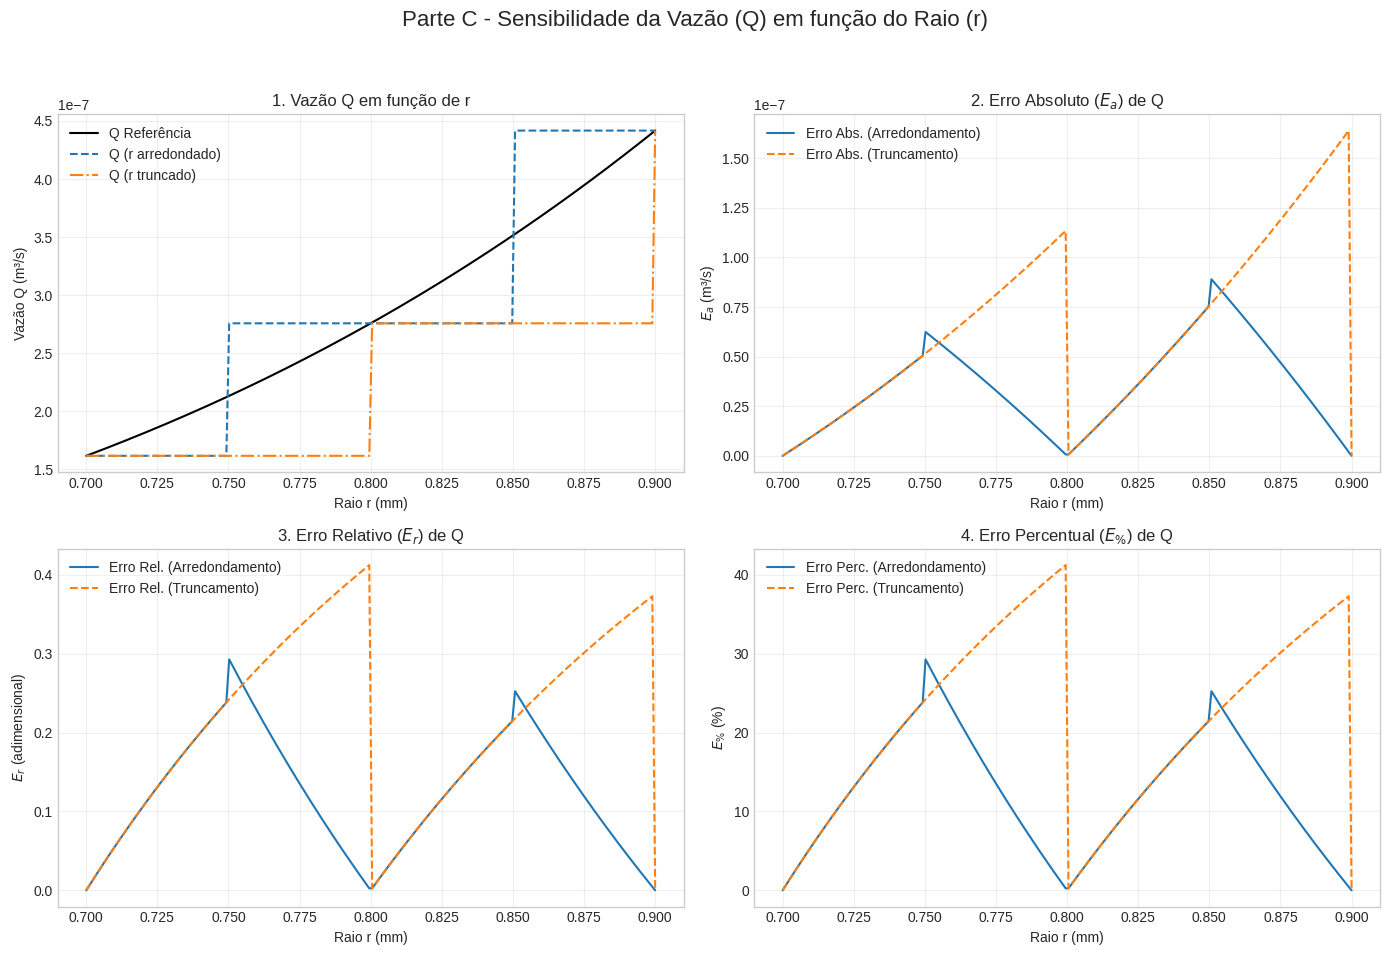

In [16]:
# Variando o raio de 0.70 a 0.90 mm
r_array_mm = np.linspace(0.70, 0.90, 200)
r_array_m = r_array_mm * 1e-3

# Vazões
Q_array_ref = hagen_poiseuille(r_array_m, dp_ref, mu_ref, L)
Q_array_round = hagen_poiseuille(np.round(r_array_mm, 1) * 1e-3, dp_ref, mu_ref, L)
Q_array_trunc = hagen_poiseuille(truncar(r_array_mm, 1) * 1e-3, dp_ref, mu_ref, L)

# Erros da aproximação por arredondamento
ea_round, er_round, ep_round = calcular_erros(Q_array_ref, Q_array_round)
# Erros da aproximação por truncamento
ea_trunc, er_trunc, ep_trunc = calcular_erros(Q_array_ref, Q_array_trunc)

# Gráficos Obrigatórios
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Parte C - Sensibilidade da Vazão (Q) em função do Raio (r)', fontsize=16)

# 1. Q em função de r
axs[0, 0].plot(r_array_mm, Q_array_ref, label='Q Referência', color='black')
axs[0, 0].plot(r_array_mm, Q_array_round, label='Q (r arredondado)', linestyle='--')
axs[0, 0].plot(r_array_mm, Q_array_trunc, label='Q (r truncado)', linestyle='-.')
axs[0, 0].set_title('1. Vazão Q em função de r')
axs[0, 0].set_xlabel('Raio r (mm)')
axs[0, 0].set_ylabel('Vazão Q (m³/s)')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# 2. Erro absoluto de Q em função de r
axs[0, 1].plot(r_array_mm, ea_round, label='Erro Abs. (Arredondamento)')
axs[0, 1].plot(r_array_mm, ea_trunc, label='Erro Abs. (Truncamento)', linestyle='--')
axs[0, 1].set_title('2. Erro Absoluto ($E_a$) de Q')
axs[0, 1].set_xlabel('Raio r (mm)')
axs[0, 1].set_ylabel('$E_a$ (m³/s)')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# 3. Erro relativo de Q em função de r
axs[1, 0].plot(r_array_mm, er_round, label='Erro Rel. (Arredondamento)')
axs[1, 0].plot(r_array_mm, er_trunc, label='Erro Rel. (Truncamento)', linestyle='--')
axs[1, 0].set_title('3. Erro Relativo ($E_r$) de Q')
axs[1, 0].set_xlabel('Raio r (mm)')
axs[1, 0].set_ylabel('$E_r$ (adimensional)')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# 4. Erro percentual de Q em função de r
axs[1, 1].plot(r_array_mm, ep_round, label='Erro Perc. (Arredondamento)')
axs[1, 1].plot(r_array_mm, ep_trunc, label='Erro Perc. (Truncamento)', linestyle='--')
axs[1, 1].set_title('4. Erro Percentual ($E_{\%}$) de Q')
axs[1, 1].set_xlabel('Raio r (mm)')
axs[1, 1].set_ylabel('$E_{\%}$ (%)')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **Por que o erro no raio é amplificado na vazão?**

Na lei de Hagen-Poiseuille, a vazão $Q$ é diretamente proporcional à quarta potência do raio ($r^4$). Matematicamente, se aplicarmos regras de propagação de erro ou diferenciação, notamos que qualquer erro relativo embutido na medida do raio será amplificado aproximadamente por um fator de 4 no resultado final da vazão. Isso explica por que pequenas flutuações, truncamentos ou falhas de arredondamento na casa decimal do raio causam saltos percentuais dramáticos (como visto nos gráficos), enquanto aproximações semelhantes em $\mu$ ou $\Delta p$ geram apenas erros proporcionais (fator 1).

# **Parte E – síntese visual**

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [18]:
# 1. Preparação Rápida dos Dados (Resumo das Partes B, C e D)
# Dados de Pressão (Parte B)
pressao = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
media_p = np.mean(pressao)

# Dados de Vazão (Parte C)
r_ref = 0.80e-3
dp_ref, mu_ref, L = 1200, 3.5e-3, 0.20
Q_ref = (np.pi * r_ref**4 * dp_ref) / (8 * mu_ref * L)

r_array = np.linspace(0.70e-3, 0.90e-3, 100)
Q_array = (np.pi * r_array**4 * dp_ref) / (8 * mu_ref * L)

# Arredondamento vs Truncamento (Erros da média de pressão)
erro_abs_round = abs(media_p - np.mean(np.round(pressao)))
erro_abs_trunc = abs(media_p - np.mean(np.trunc(pressao)))

# Precisão float32 vs float64 (Parte D)
eps32 = np.finfo(np.float32).eps
eps64 = np.finfo(np.float64).eps


/tmp/ipykernel_1252/3304801020.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


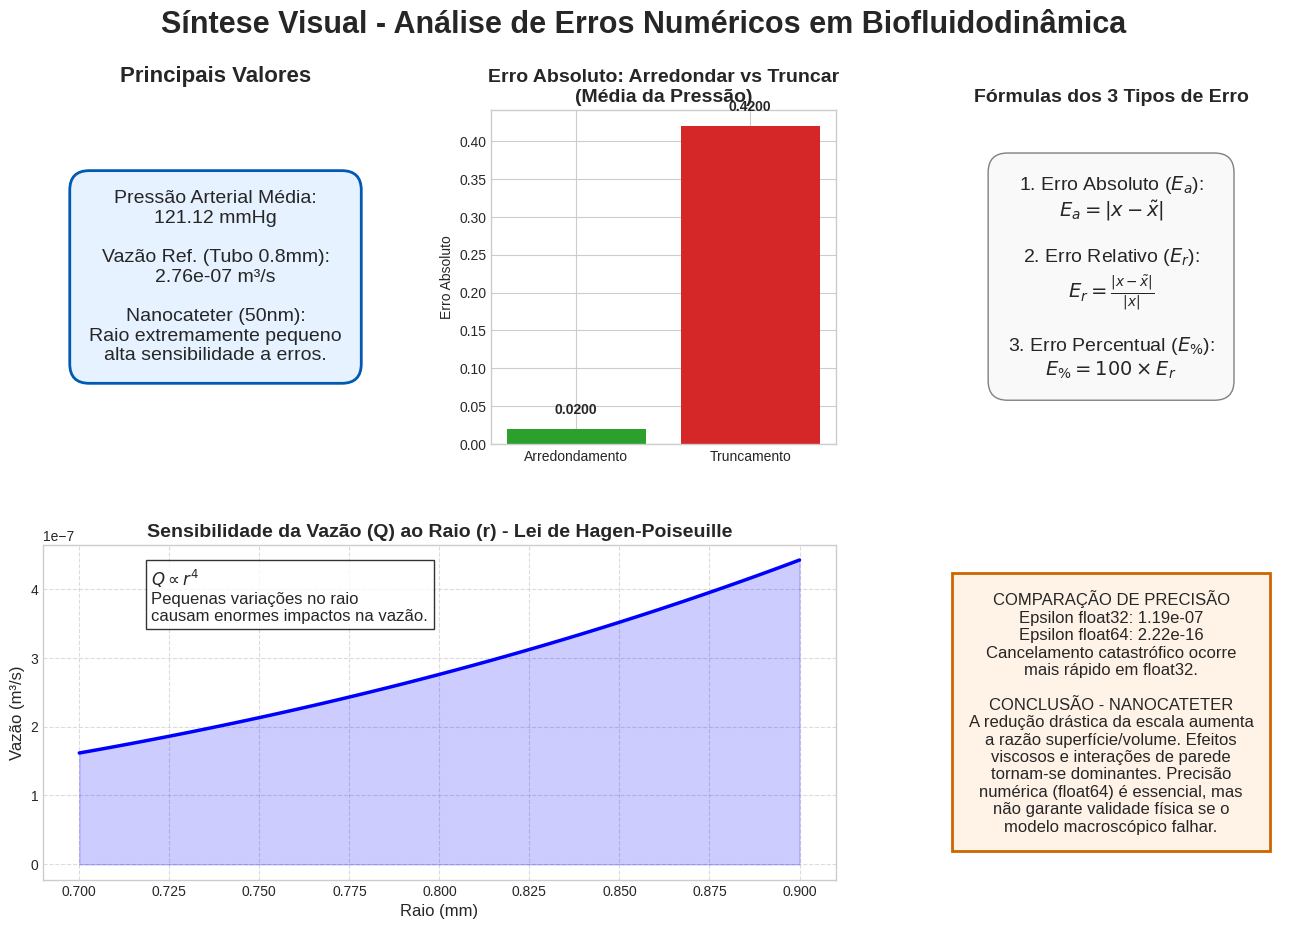

O arquivo 'quadro_resultados.png' foi salvo com sucesso (resolução base: 1600x1000).


In [19]:
# 2. Configuração do Painel (Dashboard) 1600x1000 pixels
# 16 polegadas x 10 polegadas com DPI=100 resulta em 1600x1000 pixels
fig = plt.figure(figsize=(16, 10), dpi=100)
fig.suptitle('Síntese Visual - Análise de Erros Numéricos em Biofluidodinâmica', fontsize=22, fontweight='bold', y=0.98)

# Criando um grid de 2 linhas e 3 colunas para organizar os quadros
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)


# Quadro 1: cartões com os principais valores de pressão e vazão;

ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
ax1.set_title("Principais Valores", fontsize=16, fontweight='bold', pad=20)

texto_cartoes = (
    f"Pressão Arterial Média:\n"
    f"{media_p:.2f} mmHg\n\n"
    f"Vazão Ref. (Tubo 0.8mm):\n"
    f"{Q_ref:.2e} m³/s\n\n"
    f"Nanocateter (50nm):\n"
    f"Raio extremamente pequeno\n"
    f"alta sensibilidade a erros."
)
ax1.text(0.5, 0.5, texto_cartoes, ha='center', va='center', fontsize=14,
         bbox=dict(boxstyle="round,pad=1", facecolor='#e6f2ff', edgecolor='#0059b3', linewidth=2))


# Quadro 2: comparação entre truncamento e arredondamento;

ax2 = fig.add_subplot(gs[0, 1])
categorias = ['Arredondamento', 'Truncamento']
erros_at = [erro_abs_round, erro_abs_trunc]

ax2.bar(categorias, erros_at, color=['#2ca02c', '#d62728'])
ax2.set_title("Erro Absoluto: Arredondar vs Truncar\n(Média da Pressão)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Erro Absoluto")
for i, v in enumerate(erros_at):
    ax2.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')


# Quadro 3: os três tipos de erro;

ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
ax3.set_title("Fórmulas dos 3 Tipos de Erro", fontsize=14, fontweight='bold')

texto_erros = (
    "1. Erro Absoluto ($E_a$):\n"
    "$E_a = |x - \\tilde{x}|$\n\n"
    "2. Erro Relativo ($E_r$):\n"
    "$E_r = \\frac{|x - \\tilde{x}|}{|x|}$\n\n"
    "3. Erro Percentual ($E_{\\%}$):\n"
    "$E_{\\%} = 100 \\times E_r$"
)
ax3.text(0.5, 0.5, texto_erros, ha='center', va='center', fontsize=14,
         bbox=dict(boxstyle="round,pad=1", facecolor='#f9f9f9', edgecolor='gray'))


# Quadro 4: sensibilidade de Q ao raio;
# Ocupa duas colunas para dar destaque

ax4 = fig.add_subplot(gs[1, 0:2])
ax4.plot(r_array * 1000, Q_array, 'b-', linewidth=2.5)
ax4.set_title("Sensibilidade da Vazão (Q) ao Raio (r) - Lei de Hagen-Poiseuille", fontsize=14, fontweight='bold')
ax4.set_xlabel("Raio (mm)", fontsize=12)
ax4.set_ylabel("Vazão (m³/s)", fontsize=12)
ax4.grid(True, linestyle='--', alpha=0.7)
ax4.fill_between(r_array * 1000, Q_array, alpha=0.2, color='blue')
ax4.text(0.72, max(Q_array)*0.8, "$Q \\propto r^4$\nPequenas variações no raio\ncausam enormes impactos na vazão.",
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))


# Quadro 5: Float32 vs Float64 e Conclusão (Bottom-Right)

ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

texto_conclusao = (
    "COMPARAÇÃO DE PRECISÃO\n"
    f"Epsilon float32: {eps32:.2e}\n"
    f"Epsilon float64: {eps64:.2e}\n"
    "Cancelamento catastrófico ocorre\n"
    "mais rápido em float32.\n\n"
    "CONCLUSÃO - NANOCATETER\n"
    "A redução drástica da escala aumenta\n"
    "a razão superfície/volume. Efeitos\n"
    "viscosos e interações de parede\n"
    "tornam-se dominantes. Precisão\n"
    "numérica (float64) é essencial, mas\n"
    "não garante validade física se o\n"
    "modelo macroscópico falhar."
)
ax5.text(0.5, 0.5, texto_conclusao, ha='center', va='center', fontsize=12,
         bbox=dict(boxstyle="square,pad=1", facecolor='#fff2e6', edgecolor='#cc6600', linewidth=2))


# 3. Salvando e exibindo a imagem

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('quadro_resultados.png', dpi=100, bbox_inches='tight')
plt.show()

print("O arquivo 'quadro_resultados.png' foi salvo com sucesso (resolução base: 1600x1000).")

## **GIF demonstrativo**

Gerando o GIF... Aguarde um momento.
GIF 'animacao_nanocateter.gif' gerado com sucesso!


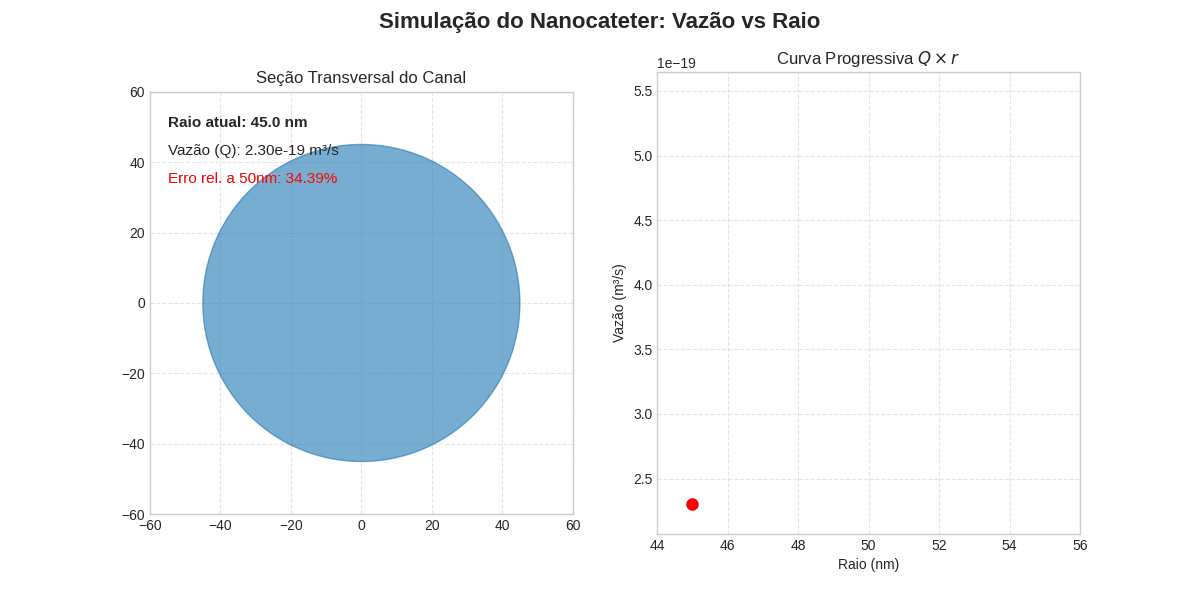

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Image, display


# 1. Configuração das Variáveis e Função de Vazão

# Constantes do nanocateter (Parte D)
L = 10e-6        # Comprimento: 10 micrometros em metros
mu = 3.5e-3      # Viscosidade em Pa.s
dp = 5000        # Diferença de pressão em Pa

def calcular_Q(r):
    """Calcula a vazão Q em função do raio r (em metros)."""
    return (np.pi * (r**4) * dp) / (8 * mu * L)

# Raio de referência (50 nm) e vazão de referência
r_ref_nm = 50.0
r_ref_m = r_ref_nm * 1e-9
Q_ref = calcular_Q(r_ref_m)

# Vetor de raios variando de 45 a 55 nm (40 quadros, respeitando a regra de 30 a 60)
r_array_nm = np.linspace(45, 55, 40)
r_array_m = r_array_nm * 1e-9
Q_array = calcular_Q(r_array_m)


# 2. Configuração da Figura para Animação

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Simulação do Nanocateter: Vazão vs Raio', fontsize=16, fontweight='bold')

# --- Painel Esquerdo (Seção Transversal e Valores) ---
ax1.set_xlim(-60, 60)
ax1.set_ylim(-60, 60)
ax1.set_aspect('equal')
ax1.set_title('Seção Transversal do Canal', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# Círculo representando o canal
circulo = plt.Circle((0, 0), r_array_nm[0], color='#1f77b4', alpha=0.6)
ax1.add_patch(circulo)

# Textos informativos
texto_raio = ax1.text(-55, 50, '', fontsize=11, fontweight='bold')
texto_vazao = ax1.text(-55, 42, '', fontsize=11)
texto_erro = ax1.text(-55, 34, '', fontsize=11, color='red')

# --- Painel Direito (Curva Q x r) ---
ax2.set_xlim(44, 56)
ax2.set_ylim(min(Q_array) * 0.9, max(Q_array) * 1.1)
ax2.set_title('Curva Progressiva $Q \\times r$', fontsize=12)
ax2.set_xlabel('Raio (nm)')
ax2.set_ylabel('Vazão (m³/s)')
ax2.grid(True, linestyle='--', alpha=0.5)

# Linha e ponto que serão atualizados
linha_q, = ax2.plot([], [], 'b-', linewidth=2)
ponto_q, = ax2.plot([], [], 'ro', markersize=8)


# 3. Funções de Animação

def iniciar():
    """Função de inicialização do fundo da animação."""
    circulo.set_radius(45)
    linha_q.set_data([], [])
    ponto_q.set_data([], [])
    texto_raio.set_text('')
    texto_vazao.set_text('')
    texto_erro.set_text('')
    return circulo, linha_q, ponto_q, texto_raio, texto_vazao, texto_erro

def atualizar(frame):
    """Atualiza cada quadro da animação."""
    r_atual_nm = r_array_nm[frame]
    Q_atual = Q_array[frame]

    # 1. Atualizar raio da seção transversal
    circulo.set_radius(r_atual_nm)

    # 2. Calcular erro percentual em relação a r=50 nm
    erro_perc = (abs(Q_atual - Q_ref) / Q_ref) * 100

    # 3. Atualizar textos
    texto_raio.set_text(f"Raio atual: {r_atual_nm:.1f} nm")
    texto_vazao.set_text(f"Vazão (Q): {Q_atual:.2e} m³/s")
    texto_erro.set_text(f"Erro rel. a 50nm: {erro_perc:.2f}%")

    # 4. Atualizar curva progressiva (fatiando os arrays até o frame atual)
    linha_q.set_data(r_array_nm[:frame+1], Q_array[:frame+1])
    ponto_q.set_data([r_atual_nm], [Q_atual]) # Atualiza iterável (lista) para os dados de x e y

    return circulo, linha_q, ponto_q, texto_raio, texto_vazao, texto_erro


# 4. Geração e Salvamento do GIF

print("Gerando o GIF... Aguarde um momento.")

# Cria a animação chamando a função 'atualizar' para cada frame
anim = FuncAnimation(fig, atualizar, frames=len(r_array_nm),
                     init_func=iniciar, blit=True, interval=150)

# Salva a animação como GIF usando o Pillow (já nativo no Colab)
nome_arquivo = 'animacao_nanocateter.gif'
anim.save(nome_arquivo, writer='pillow', fps=10)

plt.close() # Fecha a figura estática para não duplicar na tela

print(f"GIF '{nome_arquivo}' gerado com sucesso!")

# Exibe o GIF diretamente no notebook
display(Image(filename=nome_arquivo))